# Tasca S9.01. Creació de funcions, estructures de dades i bucles

Resoldràs alguns problemes de la vida quotidiana aplicant les estructures de dades i control en Python.

Un client de l'empresa en la qual treballes demana una llista de programes molt senzills, però que li facilitarien molts processos.

Se’t demanarà que programis varies funcions. Per a fer l’entrega, hauràs d’entregar tant el codi de la funció:

    def funcioexemple(variable1, variable2):
        resultat = variable1 + variable2 # sumem les dues variables
        return resultat

Com la seva execució per demostrar que funciona correctament, ensenyant-ne l’output:

    funcioexemple(3, 8)

Intenta que tot el codi que generis sigui el més reproduïble possible.

### Import libraries

In [1]:
#!pip install pandas
import pandas as pd
import re

## Nivell 1

### 1. **Calculadora de l'índex de massa corporal**

Escriu una funció que calculi l'IMC ingressat per l'usuari/ària, és a dir, qui ho executi haurà d'ingressar aquestes dades. Pots obtenir més informació del seu càlcul en: [Índice de masa corporal IMC que es y como se calcula](https://muysalud.com/salud/indice-de-masa-corporal-imc-que-es-y-como-se-calcula/).

La funció ha de classificar el resultat en les seves respectives categories.

Consell: Intenta validar les dades prèviament, perquè enviï un missatge d’advertència si les dades introduïdes per l’usuari/a no estan en el format adequat o no pren valors raonables.

In [4]:
def get_number(message):
    while True:
        try:
            value = float(input(message))
            if value <= 0:
                print("The value must be positive")
                continue
            return value
        except:
            print("Try again")

def calculate_imc():
    weight = get_number("What is your weight (kg)? ")
    height = get_number("What is your height (cm)? ") / 100

    imc = weight / (height ** 2)

    if imc < 18.5:
        category = "Bajo peso"
    elif imc <= 24.9:
        category = "Peso normal"
    elif imc <= 29.9:
        category = "Sobrepeso"
    else:
        category = "Obesidad"

    print(
        f"Peso: {weight} kg | Altura: {height:.2f} m\n"
        f"IMC: {imc:.2f} → {category}"
    )

In [5]:
calculate_imc()

Peso: 67.0 kg | Altura: 1.67 m
IMC: 24.02 → Peso normal


###  2. **Convertidor de temperatures**

Existeixen diverses unitats de temperatura utilitzades en diferents contextos i regions. Les més comunes són Celsius (°C), Fahrenheit (°F) i Kelvin (K). També existeixen altres unitats com Rankine (°Ra) i Réaumur (°Re).

Selecciona almenys 2 conversors, de tal manera que en introduir una temperatura retorni, com a mínim, dues conversions, de manera que es puguin guardar (recorda que un print() no es pot guardar mai).

Consell: Intenta validar les dades prèviament, perquè enviï un missatge d’advertència si les dades introduides per l’usuari/a no estan en el format adequat.

**Formulas:**

Celsius = (F - 32) / 1.8  
Fahrenheit = (C * 1.8) + 32

Kelvin = C + 273.15  
Celsius = K - 273.15

Kelvin = ((F-32)/ 1.8) + 273.15  
Kelvin = Celsius + 273.15

Fahrenheit = (K - 273.15) * 1.8 + 32  
Fahrenheit = Celsius * 1.8 + 32

In [11]:
def conversor():
    while True:
        origen = input('Qué unidades quieres convertir? ')

        if origen in ['Celsius', 'Fahrenheit', 'Kelvin']:
            break
        else:
            print('Unidades desconocidas')

    while True:
        try:
            valor = float(input('Cuántos grados?'))
            break
        except:
            print('try again')

    if origen == 'Celsius':
        Celsius = valor
        Fahrenheit = round((valor * 1.8) + 32,2)
        Kelvin = round(valor + 273.15,2)

    elif origen == 'Fahrenheit':
        Celsius = round((valor - 32) / 1.8  ,2)
        Fahrenheit = valor
        Kelvin = round(Celsius + 273.15,2)

    elif origen == 'Kelvin':
        Celsius = round(valor - 273.15,2)
        Fahrenheit = round(Celsius * 1.8 + 32,2)
        Kelvin = valor


    return Celsius, Fahrenheit, Kelvin
    #print(f'{Celsius:.2f} celsius'), (f'{Fahrenheit:.2f} Fahrenheit'), (f'{Kelvin:.2f} Kelvin') 

In [15]:
celsius, fahrenheit, kelvin = conversor()

In [18]:
print(f'{celsius} Celsius, {fahrenheit} Fahrenheit, {kelvin:} Kelvin')

2.0 Celsius, 35.6 Fahrenheit, 275.15 Kelvin


##### Solució més òptima (chatGPT)

La millora elegant consisteix en no fer totes les conversions directament, sinó fer-ho en dos passos:

1️⃣ Convertir sempre a Celsius (unitat intermèdia)  
2️⃣ Convertir de Celsius a la resta

Això evita repetir fórmules i simplifica molt el codi.

In [ ]:
while True:
    origen = input('Qué unidades quieres convertir? ')

    if origen in ['Celsius', 'Fahrenheit', 'Kelvin']:
        break
    else:
        print('Unidades desconocidas')


while True:
    try:
        valor = float(input('Cuántos grados? '))
        break
    except ValueError:
        print("Try again")


# convertir a Celsius
if origen == 'Celsius':
    celsius = valor

elif origen == 'Fahrenheit':
    celsius = (valor - 32) / 1.8

elif origen == 'Kelvin':
    celsius = valor - 273.15


# convertir des de Celsius
fahrenheit = round((celsius * 1.8) + 32, 2)
kelvin = round(celsius + 273.15, 2)
celsius = round(celsius, 2)


print(f"Celsius: {celsius}")
print(f"Fahrenheit: {fahrenheit}")
print(f"Kelvin: {kelvin}")

💡 Petita pista de mentor:
Molts exercicis reals fan servir números per escollir opcions, així:

1 - Celsius  
2 - Fahrenheit  
3 - Kelvin  

I llavors sí que es fa:

opcio = int(input("Escoge una opción: "))

i aquí try/except és imprescindible.

#### (EXTRA): Pensa una manera d’emmagatzemar totes les possibles conversions en un sol objecte (Llista? Diccionari? DataFrame?) en comptes d’escriure molts if else en funció de la temperatura d’origen i la temperatura de destí.

In [ ]:
def conversor():
    while True:
        origen = input('Qué unidades quieres convertir? ')

        if origen in ['Celsius', 'Fahrenheit', 'Kelvin']:
            break
        else:
            print('Unidades desconocidas')

    while True:
        try:
            valor = float(input('Cuántos grados?'))
            break
        except:
            print('try again')

    conversor_table = {
    "Celsius": [valor, ((valor * 1.8) + 32), (valor + 273.15)],
    "Fahrenheit": [((valor-32) / 1.8), valor, (((valor-32) / 1.8) + 273.15)],
    "Kelvin": [(valor - 273.15), ((valor - 273.15) * 1.8 + 32), valor]
}
    df = pd.DataFrame(conversor_table, index = ["Celsius", "Fahrenheit", "Kelvin"])
    
    celsius = df.loc["Celsius", origen]
    fahrenheit = df.loc["Fahrenheit", origen]
    kelvin = df.loc["Kelvin", origen]
    
    return celsius, fahrenheit, kelvin
    # print(f'{Celsius:.2f} celsius, {Fahrenheit:.2f} Fahrenheit, {Kelvin:.2f} Kelvin')

In [ ]:
celsius, fahrenheit, kelvin = conversor()

,Celsius,Fahrenheit,Kelvin
Celsius,2.00,-16.666667,-271.15
Fahrenheit,35.60,2.000000,-456.07
Kelvin,275.15,256.483333,2.00


2.0 35.6 275.15


##### Solució més òptima (chatGPT)

In [ ]:
def conversor():

    conversions = {
        "Celsius": {
            "Fahrenheit": lambda x: x * 1.8 + 32,
            "Kelvin": lambda x: x + 273.15
        },
        "Fahrenheit": {
            "Celsius": lambda x: (x - 32) / 1.8,
            "Kelvin": lambda x: ((x - 32) / 1.8) + 273.15
        },
        "Kelvin": {
            "Celsius": lambda x: x - 273.15,
            "Fahrenheit": lambda x: (x - 273.15) * 1.8 + 32
        }
    }

    origen = input("Unidad de origen: ").capitalize()
    
    try:
        valor = float(input("Temperatura: "))
    except ValueError:
        print("Debes introducir un número")
        return

    if origen not in conversions:
        print("Unidad no válida")
        return

    resultado = {}

    for destino, funcion in conversions[origen].items():
        resultado[destino] = funcion(valor)

    return resultado

In [ ]:
def conversor():

    to_celsius = {
        "Celsius": lambda x: x,
        "Fahrenheit": lambda x: (x - 32) / 1.8,
        "Kelvin": lambda x: x - 273.15
    }

    from_celsius = {
        "Celsius": lambda x: x,
        "Fahrenheit": lambda x: x * 1.8 + 32,
        "Kelvin": lambda x: x + 273.15
    }

    origen = input("Unidad origen: ").capitalize()
    
    try:
        valor = float(input("Temperatura: "))
    except ValueError:
        print("Número inválido")
        return

    if origen not in to_celsius:
        print("Unidad no válida")
        return

    # convertir a unidad base
    celsius = to_celsius[origen](valor)

    resultado = {}

    for destino, funcion in from_celsius.items():
        resultado[destino] = funcion(celsius)

    return resultado

### 3. Comptador de paraules d'un text.

Escriu una funció que donat un text, mostri les vegades que apareix cada paraula. Intenta que es gestionin totes les casuístiques possibles que facin que el programa no funcioni correctament.

In [2]:
text = 'Hola, em dic Sabina 2 i hola'

In [3]:
text_lower = text.lower()
text_lower

'hola, em dic sabina 2 i hola'

In [4]:
text_split = re.findall(r'\b\w+\b', text_lower) # Split the sentence using regex to keep only words
text_split

['hola', 'em', 'dic', 'sabina', '2', 'i', 'hola']

In [5]:
paraules_nombre = {}

for i in text_split:
    if i in paraules_nombre.keys():
        paraules_nombre[i] += 1
    else:
        paraules_nombre[i] = 1

In [6]:
paraules_nombre

{'hola': 2, 'em': 1, 'dic': 1, 'sabina': 1, '2': 1, 'i': 1}

In [11]:
def count_words(text:str):
    text_lower = text.lower()
    text_split = re.findall(r'\b\w+\b', text_lower) # Split the sentence using regex to keep only words
    
    paraules_nombre = {}

    for i in text_split:
        if i in paraules_nombre.keys():
            paraules_nombre[i] += 1
        else:
            paraules_nombre[i] = 1
    
    print(paraules_nombre)

In [12]:
count_words('Hola, em dic Sabina i hola 2')

{'hola': 2, 'em': 1, 'dic': 1, 'sabina': 1, 'i': 1, '2': 1}


#### (EXTRA): Quina és la llargada mitjana de les paraules del text que has escrit? “Hola com va?” hauria de retornar (4+3+2) / 3 = 3

In [15]:
def mean_length(text:str):
    text_lower = text.lower()
    text_split = re.findall(r'\b\w+\b', text_lower) # Split the sentence using regex to keep only words
    
    total_length = 0
    count = 0
    for i in text_split:
        total_length += len(i)
        count += 1
        mean = total_length / count
    print(mean)

In [16]:
mean_length('Hola, em dic Sabina i hola 2')

3.0


https://www.geeksforgeeks.org/python/python-spilt-a-sentence-into-list-of-words/
https://www.geeksforgeeks.org/python/python-regex/
https://www.w3schools.com/python/python_dictionaries_methods.asp

### 4. Diccionari invers (amb possibilitat de duplicats)

Resulta que el client té una enquesta molt antiga que s'emmagatzema en un diccionari i els resultats els necessita al revés, és a dir, intercanviant les claus i els valors. Els valors i claus en el diccionari original són únics; si aquest no és el cas, la funció hauria d'imprimir un missatge d'advertiment, juntament amb una llista amb els valors associats a la clau repetida.

Fixa’t en el següents exemples per veure l’output esperat.

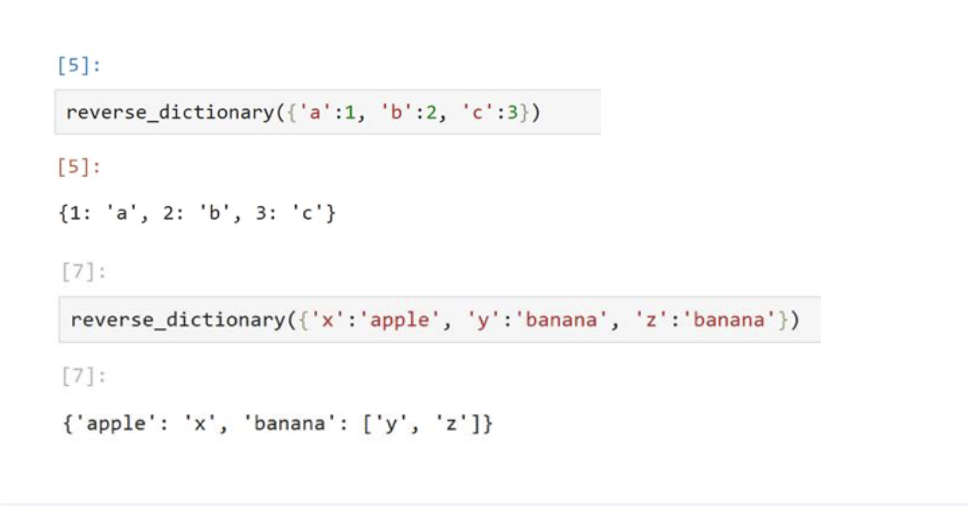

In [7]:
thisdict = {'x':'apple','y':'banana','z':'banana', 'w':'banana', 'ui':'orange','aiai':'orange'}
# 
thisdict


{'x': 'apple',
 'y': 'banana',
 'z': 'banana',
 'w': 'banana',
 'ui': 'orange',
 'aiai': 'orange'}

In [ ]:
reverse = {}

for x, y in thisdict.items():
    if y in reverse:
        if isinstance(reverse[y], str):
            reverse[y] = [reverse[y]]
        reverse[y].append(x)
    else:
        reverse[y] = x

print(reverse)

for x in reverse:
    if isinstance(reverse[x], list):
        count = len(reverse[x])
        print(f'{x} apareix {count} vegades: {", ".join(reverse[x])}')


{'apple': 'x', 'banana': ['y', 'z', 'w'], 'orange': ['ui', 'aiai']}
banana apareix 3 vegades: y, z, w
orange apareix 2 vegades: ui, aiai


https://stackoverflow.com/questions/3199171/append-multiple-values-for-one-key-in-a-dictionary
https://www.geeksforgeeks.org/python/python-append-multitype-values-in-dictionary/
https://www.geeksforgeeks.org/python/how-can-to-get-list-of-values-from-dictionary-in-python/
https://www.geeksforgeeks.org/python/python-count-number-of-items-in-a-dictionary-value-that-is-a-list/

##### Solució més òptima (chatGPT)

In [ ]:
reverse = {}

for x, y in thisdict.items():
    if y in reverse:
        if not isinstance(reverse[y], list):
            reverse[y] = [reverse[y]]
        reverse[y].append(x)
    else:
        reverse[y] = x

print(reverse)

for k, v in reverse.items():
    if isinstance(v, list):
        print(f'{k} apareix {len(v)} vegades: {", ".join(v)}')